# Anomaly Detection with SVM
**Pipeline:** Split labelled users → engineer per-user features → train SVM → evaluate on second batch

In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, RocCurveDisplay)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42

## 1. Load Data

In [2]:
first = np.load('first_batch_with_labels.npz')
X_raw = first['X']   # shape (N, 3): [user_id, feature, ?]
y_raw = first['y']   # shape (M, 2): [user_id, label]

print('X shape:', X_raw.shape)
print('y shape:', y_raw.shape)
print('X sample:\n', X_raw[:3])
print('y sample:\n', y_raw[:3])
print('Label distribution:', dict(zip(*np.unique(y_raw[:, 1], return_counts=True))))

X shape: (167493, 3)
y shape: (1100, 2)
X sample:
 [[2974    5    2]
 [2974   11    3]
 [2974   14    3]]
y sample:
 [[2500    0]
 [2501    0]
 [2502    0]]
Label distribution: {np.int64(0): np.int64(1000), np.int64(1): np.int64(100)}


## 2. Split Labelled Users → anomalous.npz / normal.npz

In [3]:
# Build lookup: user_id → label
label_map = dict(zip(y_raw[:, 0], y_raw[:, 1]))

anomalous_ids = {uid for uid, lbl in label_map.items() if lbl == 1}
normal_ids    = {uid for uid, lbl in label_map.items() if lbl == 0}

print(f'Anomalous users: {len(anomalous_ids)}')
print(f'Normal users:    {len(normal_ids)}')

# Slice rows of X by user membership
mask_anom = np.isin(X_raw[:, 0], list(anomalous_ids))
mask_norm = np.isin(X_raw[:, 0], list(normal_ids))

X_anom = X_raw[mask_anom]
X_norm = X_raw[mask_norm]

np.savez('anomalous.npz', X=X_anom)
np.savez('normal.npz',    X=X_norm)

print(f'\nanomalous.npz rows: {X_anom.shape[0]}')
print(f'normal.npz    rows: {X_norm.shape[0]}')

Anomalous users: 100
Normal users:    1000

anomalous.npz rows: 13025
normal.npz    rows: 154468


## 3. Feature Engineering (per-user aggregation)

Column layout assumed: `[user_id, event_value, flag]`  
Adjust column names/indices below if your schema differs.

In [4]:
def extract_features(X: np.ndarray) -> pd.DataFrame:
    """
    Aggregate raw rows into one feature vector per user.
    Columns: user_id=0, event_value=1, flag=2
    """
    df = pd.DataFrame(X, columns=['user_id', 'event_val', 'flag'])
    
    grp = df.groupby('user_id')
    
    feats = pd.DataFrame({
        # Event-value statistics
        'ev_count'   : grp['event_val'].count(),
        'ev_mean'    : grp['event_val'].mean(),
        'ev_std'     : grp['event_val'].std().fillna(0),
        'ev_min'     : grp['event_val'].min(),
        'ev_max'     : grp['event_val'].max(),
        'ev_range'   : grp['event_val'].max() - grp['event_val'].min(),
        'ev_median'  : grp['event_val'].median(),
        'ev_q25'     : grp['event_val'].quantile(0.25),
        'ev_q75'     : grp['event_val'].quantile(0.75),
        'ev_iqr'     : grp['event_val'].quantile(0.75) - grp['event_val'].quantile(0.25),
        # Flag statistics
        'flag_sum'   : grp['flag'].sum(),
        'flag_mean'  : grp['flag'].mean(),
        'flag_max'   : grp['flag'].max(),
        # Inter-event gaps (diff of sorted event_val per user)
        'gap_mean'   : grp['event_val'].apply(lambda x: np.diff(np.sort(x)).mean() if len(x) > 1 else 0),
        'gap_std'    : grp['event_val'].apply(lambda x: np.diff(np.sort(x)).std()  if len(x) > 1 else 0),
        'gap_max'    : grp['event_val'].apply(lambda x: np.diff(np.sort(x)).max()  if len(x) > 1 else 0),
        # Unique event count
        'ev_unique'  : grp['event_val'].nunique(),
    }).reset_index()
    
    return feats


feats_anom = extract_features(X_anom)
feats_norm = extract_features(X_norm)

feats_anom['label'] = 1
feats_norm['label'] = 0

all_feats = pd.concat([feats_anom, feats_norm], ignore_index=True)
print('Combined feature matrix:', all_feats.shape)
all_feats.describe()

Combined feature matrix: (1100, 19)


,user_id,ev_count,ev_mean,ev_std,ev_min,ev_max,ev_range,ev_median,ev_q25,ev_q75,ev_iqr,flag_sum,flag_mean,flag_max,gap_mean,gap_std,gap_max,ev_unique,label
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,3049.500000,152.266364,387.672700,219.030947,11.829091,762.299091,750.470000,391.929091,206.013864,570.605455,364.591591,514.919091,3.482766,4.960909,9.784128,11.317945,58.541818,152.266364,0.090909
std,317.686953,121.245609,153.618770,76.560264,44.210184,242.424065,245.238448,183.673277,127.837499,215.114600,152.286516,397.083918,0.530482,0.198537,11.555915,14.712403,60.821021,121.245609,0.287611
min,2500.000000,6.000000,37.850000,9.806460,0.000000,127.000000,27.000000,16.500000,5.750000,32.750000,5.000000,11.000000,1.398936,3.000000,1.174564,0.577775,5.000000,6.000000,0.000000
25%,2774.750000,58.000000,278.705054,164.103009,0.000000,597.500000,580.500000,252.000000,128.687500,411.000000,252.000000,205.750000,3.177451,5.000000,3.425932,3.471513,23.000000,58.000000,0.000000
50%,3049.500000,122.000000,391.274363,240.758432,0.000000,846.500000,831.500000,364.750000,183.250000,596.750000,390.250000,420.500000,3.539231,5.000000,5.589293,5.946497,37.000000,122.000000,0.000000
75%,3324.250000,212.000000,495.384899,281.924898,8.000000,966.000000,957.500000,526.000000,228.812500,757.562500,485.562500,724.750000,3.842253,5.000000,11.336920,13.464952,69.000000,212.000000,0.000000
max,3599.000000,806.000000,880.888889,391.274839,532.000000,999.000000,999.000000,933.000000,907.500000,954.500000,775.000000,2835.000000,5.000000,5.000000,115.285714,205.003634,603.000000,806.000000,1.000000


## 4. Train SVM Classifier

In [5]:
feature_cols = [c for c in all_feats.columns if c not in ('user_id', 'label')]

X_train = all_feats[feature_cols].values
y_train = all_feats['label'].values

# Handle class imbalance automatically
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
cw = dict(zip(classes, weights))
print('Class weights:', cw)

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=10, gamma='scale',
                   class_weight='balanced',
                   probability=True,   # needed for AUC
                   random_state=SEED))
])

# Cross-validated predictions for honest evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_pred_cv   = cross_val_predict(svm_pipe, X_train, y_train, cv=cv)
y_proba_cv  = cross_val_predict(svm_pipe, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

print('\n=== 5-Fold CV Results (first_batch) ===')
print(classification_report(y_train, y_pred_cv, target_names=['Normal', 'Anomalous']))
print(f'AUC-ROC: {roc_auc_score(y_train, y_proba_cv):.4f}')

Class weights: {np.int64(0): np.float64(0.55), np.int64(1): np.float64(5.5)}

=== 5-Fold CV Results (first_batch) ===
              precision    recall  f1-score   support

      Normal       0.98      0.88      0.93      1000
   Anomalous       0.40      0.82      0.54       100

    accuracy                           0.87      1100
   macro avg       0.69      0.85      0.73      1100
weighted avg       0.93      0.87      0.89      1100

AUC-ROC: 0.9099


In [6]:
# Fit final model on ALL labelled data
svm_pipe.fit(X_train, y_train)
print('Final model trained on', X_train.shape[0], 'users.')

Final model trained on 1100 users.


## 5. Predict on Second Batch

In [7]:
second = np.load('second_batch.npz')
# Accept either 'X' key or first available array
key2 = 'X' if 'X' in second else list(second.keys())[0]
X2_raw = second[key2]
print('Second batch shape:', X2_raw.shape)

feats2 = extract_features(X2_raw)
X2 = feats2[feature_cols].values

preds2  = svm_pipe.predict(X2)
proba2  = svm_pipe.predict_proba(X2)[:, 1]

results2 = feats2[['user_id']].copy()
results2['predicted_label'] = preds2
results2['anomaly_proba']   = proba2

print(f'\nSecond batch predictions:')
print(results2['predicted_label'].value_counts().rename({0:'Normal', 1:'Anomalous'}))
results2.head(10)

Second batch shape: (134594, 3)

Second batch predictions:
predicted_label
Normal       739
Anomalous    121
Name: count, dtype: int64


,user_id,predicted_label,anomaly_proba
0,4100,0,0.016685
1,4101,0,0.000373
2,4102,0,0.001026
3,4103,0,0.002329
4,4104,0,0.003640
5,4105,0,0.000743
6,4106,0,0.007723
7,4107,0,0.003937
8,4108,0,0.036517
9,4109,0,0.008316


### (Optional) Evaluate second batch if ground-truth labels are available

## 6. Visualisations

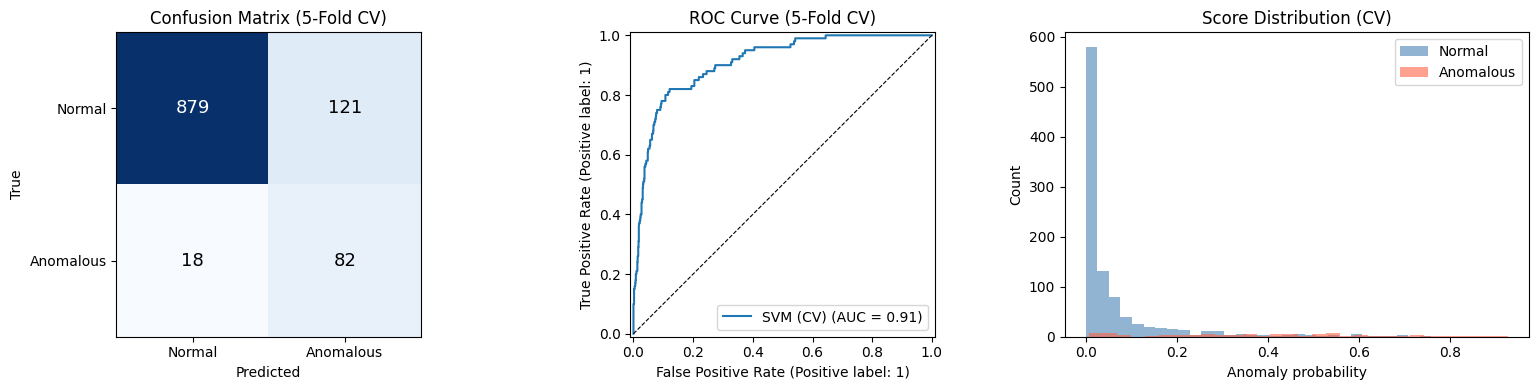

Saved evaluation_plots.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Confusion matrix (CV) ---
cm = confusion_matrix(y_train, y_pred_cv)
im = axes[0].imshow(cm, cmap='Blues')
for (r, c), v in np.ndenumerate(cm):
    axes[0].text(c, r, v, ha='center', va='center', fontsize=13,
                 color='white' if v > cm.max()/2 else 'black')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Normal', 'Anomalous'])
axes[0].set_yticklabels(['Normal', 'Anomalous'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (5-Fold CV)')

# --- ROC curve (CV) ---
RocCurveDisplay.from_predictions(y_train, y_proba_cv, ax=axes[1],
                                  name='SVM (CV)')
axes[1].plot([0,1],[0,1],'k--', linewidth=0.8)
axes[1].set_title('ROC Curve (5-Fold CV)')

# --- Score distribution ---
axes[2].hist(y_proba_cv[y_train==0], bins=30, alpha=0.6, label='Normal',    color='steelblue')
axes[2].hist(y_proba_cv[y_train==1], bins=30, alpha=0.6, label='Anomalous', color='tomato')
axes[2].set_xlabel('Anomaly probability'); axes[2].set_ylabel('Count')
axes[2].set_title('Score Distribution (CV)')
axes[2].legend()

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150)
plt.show()
print('Saved evaluation_plots.png')

## 7. Feature Importances (via permutation)

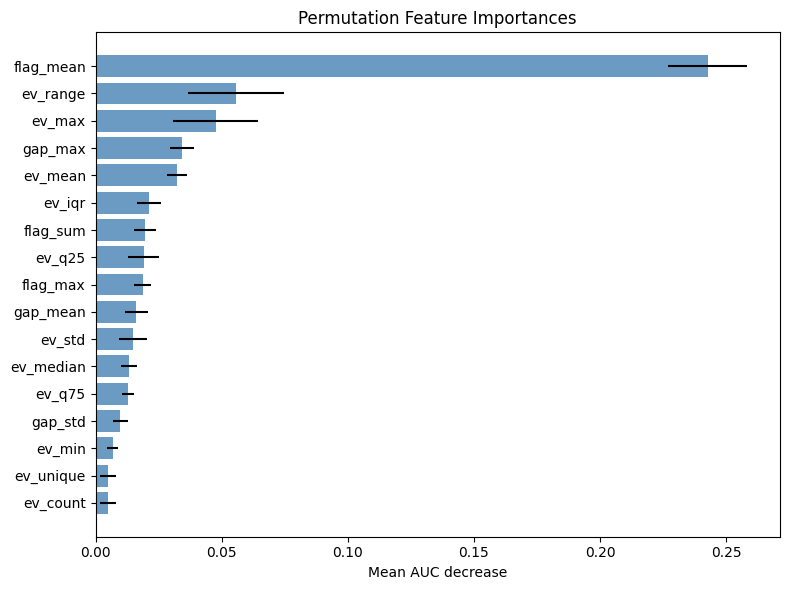

Saved feature_importances.png


In [10]:
from sklearn.inspection import permutation_importance

pi = permutation_importance(svm_pipe, X_train, y_train,
                             n_repeats=10, random_state=SEED,
                             scoring='roc_auc')

fi_df = pd.DataFrame({'feature': feature_cols,
                       'importance_mean': pi.importances_mean,
                       'importance_std' : pi.importances_std})
fi_df = fi_df.sort_values('importance_mean', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df['feature'], fi_df['importance_mean'],
        xerr=fi_df['importance_std'], color='steelblue', alpha=0.8)
ax.set_xlabel('Mean AUC decrease'); ax.set_title('Permutation Feature Importances')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150)
plt.show()
print('Saved feature_importances.png')

## 8. Save Predictions

In [12]:
import zipfile

# Normalise scores to [0, 1]
y_score_norm = (proba2 - proba2.min()) / (proba2.max() - proba2.min())

# Save submission
np.savez('submission.npz', predictions=y_score_norm)
with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('submission.npz', arcname='submission.npz')
pd.DataFrame({'predictions': y_score_norm}).to_csv('submission.csv', index=False)

print(f'Users predicted : {feats2["user_id"].nunique()}')
print(f'First 5 user IDs: {feats2["user_id"].values[:5]}')
print(f'Score range     : [{y_score_norm.min():.4f}, {y_score_norm.max():.4f}]')
print('submission.zip ready for Codabench')

Users predicted : 860
First 5 user IDs: [4100 4101 4102 4103 4104]
Score range     : [0.0000, 1.0000]
submission.zip ready for Codabench
